# 00 Data Exploration

## Purpose

This is the first notebook in the rebuilt workflow. I am using it to inspect the raw dataset before making any splits.

## Inputs

- `MyDrive/ProjectRoot/data/raw/raw_glycans_dataset_no_aldi.txt`

## Outputs

- quick printed dataset summary
- sequence length distribution plot
- summary CSV saved to Drive

## Notes to myself

This notebook should stay lightweight. I just want to confirm the raw file is correct, look at sequence lengths, and save a basic reference figure.

## Why the setup cell looks like this

I am separating code from heavy outputs right away so the workflow is easier to reproduce.

- the code and notebooks live in GitHub
- the raw data and generated outputs live in Drive
- Colab pulls the repo at the start, and I can save notebook edits back to GitHub separately if I need to

The repo stays clean and Drive holds the large files.

In [11]:
# ==============================================================================
# 0. SET UP THE COLAB ENVIRONMENT
# ==============================================================================
import os
import sys

from google.colab import drive

# Mount Google Drive so the notebook can read data files and save outputs.
drive.mount('/content/drive')

# Clone the public GitHub repository into the Colab runtime.
GITHUB_OWNER = 'hb791-dev'
REPO_NAME = 'glycan-roberta'
REPO_URL = f'https://github.com/{GITHUB_OWNER}/{REPO_NAME}.git'
REPO_DIR = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_DIR):
    print('Cloning repository...')
    !git clone -q {REPO_URL} {REPO_DIR}
else:
    print('Repository already exists. Pulling latest changes...')

%cd {REPO_DIR}
!git pull origin main --no-edit -q

# Add the repo to the Python path so src/ imports work across notebooks.
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

print('Colab environment ready.')
print(f'Repo directory: {REPO_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repository already exists. Pulling latest changes...
/content/glycan-roberta
Colab environment ready.
Repo directory: /content/glycan-roberta


## Path setup

I want the important paths defined once near the top. For this notebook, the main things I care about are:

- where the new Drive project root lives
- where the raw data file lives
- where the exploration outputs should go

I am also creating the results folder here instead of assuming it already exists.

In [12]:
# ==============================================================================
# 1. DEFINE THE DRIVE PATHS FOR THIS NOTEBOOK
# ==============================================================================
PROJECT_ROOT = '/content/drive/MyDrive/ProjectRoot'
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'raw_glycans_dataset_no_aldi.txt')
EXPLORATION_RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'exploration')

os.makedirs(EXPLORATION_RESULTS_DIR, exist_ok=True)

print('Project root:')
print(PROJECT_ROOT)
print('\nRaw data path:')
print(RAW_DATA_PATH)
print('\nExploration results directory:')
print(EXPLORATION_RESULTS_DIR)

if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(f'Raw dataset not found: {RAW_DATA_PATH}')


Project root:
/content/drive/MyDrive/ProjectRoot

Raw data path:
/content/drive/MyDrive/ProjectRoot/data/raw/raw_glycans_dataset_no_aldi.txt

Exploration results directory:
/content/drive/MyDrive/ProjectRoot/results/exploration


## Basic dataset summary

At this stage I want to answer a few simple questions:

- how many sequences are in the file
- what do a few example sequences look like
- how long are the sequences in characters

I am using character length here because tokenizers do not exist yet. Later, token length will matter more.

In [13]:
# ==============================================================================
# 2. LOAD THE RAW DATASET AND COMPUTE BASIC SUMMARY STATISTICS
# ==============================================================================
import numpy as np
import pandas as pd

with open(RAW_DATA_PATH, 'r', encoding='utf-8') as file:
    glycan_sequences = [line.strip() for line in file if line.strip()]

sequence_lengths = np.array([len(sequence) for sequence in glycan_sequences])

dataset_summary = pd.DataFrame(
    {
        'metric': [
            'num_sequences',
            'min_char_length',
            'mean_char_length',
            'median_char_length',
            'max_char_length',
            'p95_char_length',
            'p99_char_length',
        ],
        'value': [
            len(glycan_sequences),
            int(sequence_lengths.min()),
            float(sequence_lengths.mean()),
            float(np.median(sequence_lengths)),
            int(sequence_lengths.max()),
            float(np.percentile(sequence_lengths, 95)),
            float(np.percentile(sequence_lengths, 99)),
        ],
    }
)

print('Dataset summary')
display(dataset_summary)

preview_count = min(5, len(glycan_sequences))
preview_df = pd.DataFrame(
    {
        'example_index': list(range(preview_count)),
        'sequence': glycan_sequences[:preview_count],
        'char_length': [len(sequence) for sequence in glycan_sequences[:preview_count]],
    }
)

print('\nExample sequences')
display(preview_df)

Dataset summary


,metric,value
0,num_sequences,21817.000000
1,min_char_length,3.000000
2,mean_char_length,70.155933
3,median_char_length,66.000000
4,max_char_length,320.000000
5,p95_char_length,139.000000
6,p99_char_length,168.000000



Example sequences


,example_index,sequence,char_length
0,0,NeuGc?2-?NeuGc?2-?Gal?1-?Glc,28
1,1,Gal?1-4GlcNAc?1-?(Gal?1-4GlcNAc?1-2)Man?1-3(Ne...,101
2,2,Glcb1-3Glcb1-3Glcb,18
3,3,Fuca1-3(Galb1-4)Glc,19
4,4,Glcb1-4Glcb1-4Glcb1-4Glcb,25


## Sequence length plot

This plot is here to show whether the raw dataset has a long tail of very large glycans. That matters later when I choose padding and truncation rules.

What I am looking for:

- whether most glycans are fairly compact
- whether there are a few very long outliers
- whether the distribution looks stable enough that percentile-based length cutoffs will make sense later

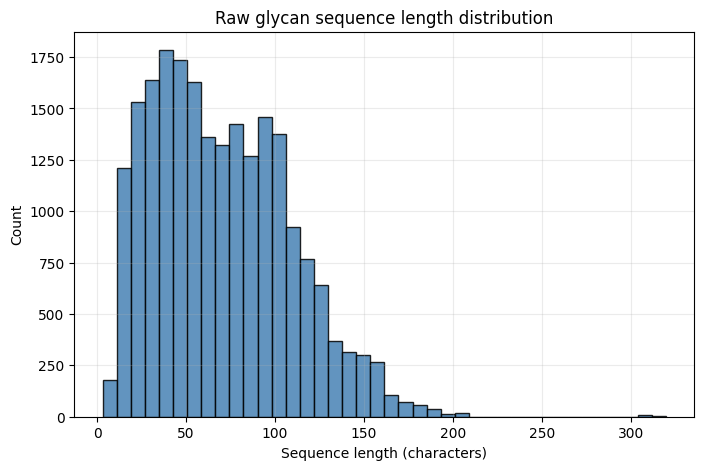

Plot saved to: /content/drive/MyDrive/ProjectRoot/results/exploration/sequence_length_distribution.png


In [14]:
# ==============================================================================
# 3. PLOT THE RAW SEQUENCE LENGTH DISTRIBUTION
# ==============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(sequence_lengths, bins=40, color='steelblue', edgecolor='black', alpha=0.85)
plt.xlabel('Sequence length (characters)')
plt.ylabel('Count')
plt.title('Raw glycan sequence length distribution')
plt.grid(alpha=0.25)

plot_path = os.path.join(EXPLORATION_RESULTS_DIR, 'sequence_length_distribution.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Plot saved to: {plot_path}')

## Save lightweight outputs

I want this notebook to leave behind a small paper trail in Drive. Saving the summary now makes later comparisons easier.

In [15]:
# ==============================================================================
# 4. SAVE THE SUMMARY TABLES
# ==============================================================================
summary_path = os.path.join(EXPLORATION_RESULTS_DIR, 'dataset_summary.csv')
preview_path = os.path.join(EXPLORATION_RESULTS_DIR, 'example_sequences.csv')

dataset_summary.to_csv(summary_path, index=False)
preview_df.to_csv(preview_path, index=False)

print(f'Dataset summary saved to: {summary_path}')
print(f'Example sequence preview saved to: {preview_path}')

Dataset summary saved to: /content/drive/MyDrive/ProjectRoot/results/exploration/dataset_summary.csv
Example sequence preview saved to: /content/drive/MyDrive/ProjectRoot/results/exploration/example_sequences.csv
